## Part 1- Data Coding and Merging

I. Data Coding and Merging

Import the “NHL_Team.csv” data file and name the dataframe as “NHL_Team” in Jupyter Notebook.
a) Delete the following variables: “Unnamed:0”, “abbr”, “tname”, “lname”, and “sname”.
b) Rename the variable “name” to “team_name”.

Import the “NHL_competition.csv” data file and name the dataframe as “NHL_Competition” in Jupyter Notebook.
a) Delete the following variables: “Unnamed: 0”, “tz”, “start”, and “end”
b) Rename the variable “name” to “competition_name”.

Import the “NHL_game.csv” data file and name the dataframe as “NHL_Game” in Jupyter Notebook.
a) Delete the following variables: “X”, “period”, and “status”.

Merge the dataframe “NHL_Team” into the dataframe “NHL_Game” by “tid.” Continue to name the merged dataframe as “NHL_Game.”

Merge the dataframe “NHL_Competition” into the dataframe “NHL_Game” by “comp_id.” Continue to name the merged dataframe as “NHL_Game.”

In the merged “NHL_Game” dataframe, create a variable “hgd” to indicate the goal difference between home and away score (hscore – ascore) and delete observations with missing value in the variable “hgd”.

Drop all observations with missing values, if there is still any, from the “NHL_Game” dataframe.

Convert the type of the “date” variable from “object” to “datetime.”

Sort the NHL games by “date” and show the first 15 observations.

Create two dataframes that separate the “NHL_Game” dataframe by home and away games. Name them “NHL_Home” and “NHL_Away”, respectively.
a) Rename variables:
     i) For away games, rename “ascore” to “goals_for”; rename “hscore” to “goals_against”
     ii) For home games, rename “hscore” to “goals_for”; rename “ascore” to “goals_against” 
b) Create a “win” variable that equals to 1 if the team won the game; 0 if the team lost the game; and 0.5 if it was a draw. 

Append the “NHL_Home” and “NHL_Away” dataframes to be the new “NHL_Game” dataframe.

Generate a team level dataframe that aggregates the total number of games won, the total number of “goals_for” and “goals_against” for each team in each competition (i.e. grouped by tid, competition_name and type). Name this new dataframe “NHL_Team_Stats”. Make sure to convert the indexes of the new dataframe back as  variables. 

Create a dataframe “NHL_Game_Count” that include the total number of games played by each team in each competition (i.e. grouped by tid, competition_name and type). Name this new variable in the dataframe “game_count”.

Merge dataframes.
a) Merge the “NHL_Game_Count” dataframe into the “NHL_Team_Stats” dataframe by “tid”, “competition_name”, and “type”. Continue to name the merged dataframe “NHL_Team_Stats”.
b) Merge the “NHL_Team” dataframe into the “NHL_Team_Stats” dataframe by “tid”. Continue to name the merged dataframe “NHL_Team_Stats”.

Import the “pp.pk.ppgf.csv” data file and name the dataframe as “NHL_PPPK” in Jupyter Notebook. Merge the “NHL_PPPK” dataframe into the “NHL_Team_Stats” dataframe by “tricode” and “competition_name”.

Create new variables in the “NHL_Team_Stats” dataframe.
a) Winning percentage (“win_pct”)=”win”/ total number of games played
b) Average goals for per game (“avg_gf”)=total number of goals for / total number of games played     
c) Average goals against per game (“avg_ga”)=total number of goals against / total number of games played

In the “NHL_Competition” dataframe, the variable “type” indicates the type of competition: type=2 – regular season. Create a dataframe that contains team statistics for games only during regular seasons. Name this dataframe “NHL_Team_R_Stats”. 

In [23]:
#Import Libraries

import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#Import NHL Team Data and Display
NHL_Team=pd.read_csv("Assignment Data/Week 2/NHL_team.csv")
display(NHL_Team)

,Unnamed: 0,tid,name,tname,lname,tricode,abbr,sname
0,1,1,Toronto Maple Leafs,Maple Leafs,Toronto,TOR,TOR,Toronto
1,2,2,Montréal Canadiens,Canadiens,Montréal,MTL,MTL,Montréal
2,3,4,Winnipeg Jets,Jets,Winnipeg,WPG,WPG,Winnipeg
3,4,5,Washington Capitals,Capitals,Washington,WSH,WSH,Washington
4,5,6,Chicago Blackhawks,Blackhawks,Chicago,CHI,CHI,Chicago
5,6,7,St. Louis Blues,Blues,St. Louis,STL,STL,St Louis
6,7,8,Pittsburgh Penguins,Penguins,Pittsburgh,PIT,PIT,Pittsburgh
7,8,10,Edmonton Oilers,Oilers,Edmonton,EDM,EDM,Edmonton
8,9,11,Calgary Flames,Flames,Calgary,CGY,CGY,Calgary
9,10,14,Philadelphia Flyers,Flyers,Philadelphia,PHI,PHI,Philadelphia


In [25]:
# Import the “NHL_Team.csv” data file and name the dataframe as “NHL_Team” in Jupyter Notebook. a) Delete the following variables: “Unnamed:0”, “abbr”, “tname”, “lname”, and “sname”. b) Rename the variable “name” to “team_name”.

NHL_Team.drop(columns=["Unnamed: 0", "abbr", "tname", "lname","sname"],axis=1,inplace=True)
NHL_Team = NHL_Team.rename(columns={"name":"team_name"})
display(NHL_Team)

,tid,team_name,tricode
0,1,Toronto Maple Leafs,TOR
1,2,Montréal Canadiens,MTL
2,4,Winnipeg Jets,WPG
3,5,Washington Capitals,WSH
4,6,Chicago Blackhawks,CHI
5,7,St. Louis Blues,STL
6,8,Pittsburgh Penguins,PIT
7,10,Edmonton Oilers,EDM
8,11,Calgary Flames,CGY
9,14,Philadelphia Flyers,PHI


In [26]:
#Import NHL Competition Data and Display Head
NHL_Competition=pd.read_csv("Assignment Data/Week 2/NHL_competition.csv")
NHL_Competition.head()

,Unnamed: 0,comp_id,year,type,name,tz,start,end
0,1,1,2013,2,2013 NHL Regular Season,ET,NaN,NaN
1,2,2,2017,2,2017 NHL Regular Season,ET,NaN,NaN
2,3,2453,2013,3,2013 NHL Playoff,ET,NaN,NaN
3,4,2541,2017,3,2017 NHL Playoff,ET,NaN,NaN
4,5,2661,2012,2,2012 NHL Regular Season,ET,NaN,NaN


In [27]:
# a) Delete the following variables: “Unnamed: 0”, “tz”, “start”, and “end” b) Rename the variable “name” to “competition_name”.

NHL_Competition.drop(columns=["Unnamed: 0", "tz", "start", "end"],axis=1,inplace=True)
NHL_Competition = NHL_Competition.rename(columns={"name":"competition_name"})
NHL_Competition.head()

,comp_id,year,type,competition_name
0,1,2013,2,2013 NHL Regular Season
1,2,2017,2,2017 NHL Regular Season
2,2453,2013,3,2013 NHL Playoff
3,2541,2017,3,2017 NHL Playoff
4,2661,2012,2,2012 NHL Regular Season


In [28]:
#Import NHL Game Data and Display Head
NHL_Game=pd.read_csv("Assignment Data/Week 2/NHL_game.csv")
NHL_Game.head()

,X,gid,comp_id,date,ascore,hscore,period,status,home_away,tid
0,1,37,2,10/7/2017,NaN,NaN,NaN,NaN,away,25
1,2,67,2,10/9/2017,NaN,NaN,NaN,NaN,away,29
2,3,154,1,10/14/2013,NaN,NaN,NaN,NaN,away,29
3,4,278,1,10/24/2013,NaN,NaN,NaN,NaN,away,53
4,5,291,1,10/25/2013,NaN,NaN,NaN,NaN,away,5


In [29]:
# a) Delete the following variables: “X”, “period”, and “status”.

NHL_Game.drop(columns=['X','period','status'],axis=1,inplace=True)
NHL_Game.head()

,gid,comp_id,date,ascore,hscore,home_away,tid
0,37,2,10/7/2017,NaN,NaN,away,25
1,67,2,10/9/2017,NaN,NaN,away,29
2,154,1,10/14/2013,NaN,NaN,away,29
3,278,1,10/24/2013,NaN,NaN,away,53
4,291,1,10/25/2013,NaN,NaN,away,5


In [30]:
# Merge the dataframe “NHL_Team” into the dataframe “NHL_Game” by “tid.” Continue to name the merged dataframe as “NHL_Game.”

NHL_Game = pd.merge(NHL_Team,NHL_Game,on='tid')

In [31]:
# Merge the dataframe “NHL_Competition” into the dataframe “NHL_Game” by “comp_id.” Continue to name the merged dataframe as “NHL_Game.”

NHL_Game = pd.merge(NHL_Competition,NHL_Game,on='comp_id')
# In the merged “NHL_Game” dataframe, create a variable “hgd” to indicate the goal difference between home and away score (hscore – ascore) and delete observations with missing value in the variable “hgd”.

NHL_Game['hgd'] = NHL_Game['hscore'] - NHL_Game['ascore']
NHL_Game = NHL_Game.dropna(subset=['hgd'])


In [32]:
# Drop all observations with missing values, if there is still any, from the “NHL_Game” dataframe.

NHL_Game = NHL_Game.dropna()
NHL_Game.shape

(18506, 13)

In [35]:
# Convert the type of the “date” variable from “object” to “datetime.”
NHL_Game['date'] = pd.to_datetime(NHL_Game['date'])

# Sort the NHL games by “date” and show the first 15 observations.
NHL_Game.sort_values(by='date').head(15)

,comp_id,year,type,competition_name,tid,team_name,tricode,gid,date,ascore,hscore,home_away,hgd
15183,5662,2010,2,2010 NHL Regular Season,35,Minnesota Wild,MIN,5666,2010-10-07,4.0,3.0,home,-1.0
14163,5662,2010,2,2010 NHL Regular Season,14,Philadelphia Flyers,PHI,5664,2010-10-07,3.0,2.0,away,-1.0
15794,5662,2010,2,2010 NHL Regular Season,66,Carolina Hurricanes,CAR,5666,2010-10-07,4.0,3.0,away,-1.0
13955,5662,2010,2,2010 NHL Regular Season,8,Pittsburgh Penguins,PIT,5664,2010-10-07,3.0,2.0,home,-1.0
13611,5662,2010,2,2010 NHL Regular Season,2,Montréal Canadiens,MTL,5662,2010-10-07,2.0,3.0,away,1.0
13564,5662,2010,2,2010 NHL Regular Season,1,Toronto Maple Leafs,TOR,5662,2010-10-07,2.0,3.0,home,1.0
14796,5662,2010,2,2010 NHL Regular Season,22,Colorado Avalanche,COL,5668,2010-10-08,3.0,4.0,home,1.0
15675,5662,2010,2,2010 NHL Regular Season,52,Columbus Blue Jackets,CBJ,5672,2010-10-08,3.0,2.0,home,-1.0
14664,5662,2010,2,2010 NHL Regular Season,21,Anaheim Ducks,ANA,5679,2010-10-08,0.0,4.0,away,4.0
13672,5662,2010,2,2010 NHL Regular Season,5,Washington Capitals,WSH,5683,2010-10-08,2.0,4.0,away,2.0


In [36]:
# Create two dataframes that separate the “NHL_Game” dataframe by home and away games. Name them “NHL_Home” and “NHL_Away”, respectively. a) Rename variables: i) For away games, rename “ascore” to “goals_for”; rename “hscore” to “goals_against” ii) For home games, rename “hscore” to “goals_for”; rename “ascore” to “goals_against” b) Create a “win” variable that equals to 1 if the team won the game; 0 if the team lost the game; and 0.5 if it was a draw.
NHL_Home = NHL_Game[NHL_Game['home_away']=='home']
NHL_Away = NHL_Game[NHL_Game['home_away']=='away']
NHL_Away = NHL_Away.rename(columns={'ascore':'goals_for','hscore':'goals_against'})
NHL_Home = NHL_Home.rename(columns={'ascore':'goals_against','hscore':'goals_for'})
NHL_Home['win'] = np.where(NHL_Home['hgd']>0,1,np.where(NHL_Home['hgd']==0,0.5,0))
NHL_Away['win'] = np.where(NHL_Away['hgd']<0,1,np.where(NHL_Away['hgd']==0,0.5,0))

# Append the “NHL_Home” and “NHL_Away” dataframes to be the new “NHL_Game” dataframe.
NHL_Game = pd.concat([NHL_Home, NHL_Away], ignore_index=True)
NHL_Game.head()


,comp_id,competition_name,date,gid,goals_against,goals_for,hgd,home_away,team_name,tid,tricode,type,win,year
0,1,2013 NHL Regular Season,2013-10-26,307,1.0,4.0,3.0,home,Toronto Maple Leafs,1,TOR,2,1.0,2013
1,1,2013 NHL Regular Season,2013-11-24,682,2.0,3.0,1.0,home,Toronto Maple Leafs,1,TOR,2,1.0,2013
2,1,2013 NHL Regular Season,2014-03-25,2150,5.0,3.0,-2.0,home,Toronto Maple Leafs,1,TOR,2,0.0,2013
3,1,2013 NHL Regular Season,2014-03-19,2067,5.0,3.0,-2.0,home,Toronto Maple Leafs,1,TOR,2,0.0,2013
4,1,2013 NHL Regular Season,2014-04-03,2281,3.0,4.0,1.0,home,Toronto Maple Leafs,1,TOR,2,1.0,2013


In [37]:
# Generate a team level dataframe that aggregates the total number of games won, the total number of “goals_for” and “goals_against” for each team in each competition (i.e. grouped by tid, competition_name and type). Name this new dataframe “NHL_Team_Stats”. Make sure to convert the indexes of the new dataframe back as variables.
NHL_Team_Stats = NHL_Game.groupby(['tid', 'competition_name', 'type']).agg({
    'win': 'sum',
    'goals_for': 'sum',
    'goals_against': 'sum'
}).reset_index()

# Optional: View the first few rows
print(NHL_Team_Stats.head())

   tid         competition_name  type   win  goals_for  goals_against
0    1  2010 NHL Regular Season     2  36.0      223.0          259.0
1    1  2011 NHL Regular Season     2  20.0      129.0          129.0
2    1         2012 NHL Playoff     3   3.0       18.0           22.0
3    1  2012 NHL Regular Season     2  25.0      144.0          129.0
4    1  2013 NHL Regular Season     2  38.0      231.0          250.0


In [38]:
# Create a dataframe “NHL_Game_Count” that include the total number of games played by each team in each competition (i.e. grouped by tid, competition_name and type). Name this new variable in the dataframe “game_count”.
NHL_Game_Count = NHL_Game.groupby(['tid', 'competition_name', 'type']).size().reset_index(name='game_count')

# View the result
print(NHL_Game_Count.head())

   tid         competition_name  type  game_count
0    1  2010 NHL Regular Season     2          82
1    1  2011 NHL Regular Season     2          40
2    1         2012 NHL Playoff     3           7
3    1  2012 NHL Regular Season     2          46
4    1  2013 NHL Regular Season     2          79


In [39]:
# Merge dataframes. a) Merge the “NHL_Game_Count” dataframe into the “NHL_Team_Stats” dataframe by “tid”, “competition_name”, and “type”. Continue to name the merged dataframe “NHL_Team_Stats”. b) Merge the “NHL_Team” dataframe into the “NHL_Team_Stats” dataframe by “tid”. Continue to name the merged dataframe “NHL_Team_Stats”.
NHL_Team_Stats = pd.merge(
    NHL_Team_Stats, 
    NHL_Game_Count, 
    on=['tid', 'competition_name', 'type'], 
    how='inner'
)

NHL_Team_Stats = pd.merge(
    NHL_Team_Stats, 
    NHL_Team, 
    on='tid', 
    how='inner'
)

In [40]:
#Import NHL PPPK Data and Display Head
NHL_PPPK=pd.read_csv("Assignment Data/Week 2/pp.pk.ppgf.csv")

NHL_Team_Stats = pd.merge(
    NHL_Team_Stats, 
    NHL_PPPK, 
    on=['tricode', 'competition_name'], 
    how='inner'
)

In [41]:
# Create new variables in the “NHL_Team_Stats” dataframe. a) Winning percentage (“win_pct”)=”win”/ total number of games played b) Average goals for per game (“avg_gf”)=total number of goals for / total number of games played
# c) Average goals against per game (“avg_ga”)=total number of goals against / total number of games played
NHL_Team_Stats['win_pct']=NHL_Team_Stats['win']/NHL_Team_Stats['game_count']
NHL_Team_Stats['avg_gf']=NHL_Team_Stats['goals_for']/NHL_Team_Stats['game_count']
NHL_Team_Stats['avg_ga']=NHL_Team_Stats['goals_against']/NHL_Team_Stats['game_count']

In [65]:
# In the “NHL_Competition” dataframe, the variable “type” indicates the type of competition: type=2 – regular season. Create a dataframe that contains team statistics for games only during regular seasons. Name this dataframe “NHL_Team_R_Stats”.

NHL_Team_R_Stats = NHL_Team_Stats[NHL_Team_Stats['type']==2]
NHL_Team_R_Stats

,tid,competition_name,type,win,goals_for,goals_against,game_count,team_name,tricode,pp,pk,ppgf,win_pct,avg_gf,avg_ga
0,1,2010 NHL Regular Season,2,36.0,223.0,259.0,82,Toronto Maple Leafs,TOR,368,426,46.0,0.439024,2.719512,3.158537
1,1,2011 NHL Regular Season,2,20.0,129.0,129.0,40,Toronto Maple Leafs,TOR,192,182,36.0,0.500000,3.225000,3.225000
3,1,2012 NHL Regular Season,2,25.0,144.0,129.0,46,Toronto Maple Leafs,TOR,234,230,39.0,0.543478,3.130435,2.804348
4,1,2013 NHL Regular Season,2,38.0,231.0,250.0,79,Toronto Maple Leafs,TOR,362,342,61.0,0.481013,2.924051,3.164557
5,1,2014 NHL Regular Season,2,29.0,209.0,258.0,78,Toronto Maple Leafs,TOR,319,343,54.0,0.371795,2.679487,3.307692
6,1,2015 NHL Regular Season,2,29.0,196.0,238.0,79,Toronto Maple Leafs,TOR,324,307,27.0,0.367089,2.481013,3.012658
8,1,2016 NHL Regular Season,2,40.0,255.0,246.0,82,Toronto Maple Leafs,TOR,321,321,69.0,0.487805,3.109756,3.000000
10,1,2017 NHL Regular Season,2,47.0,268.0,232.0,79,Toronto Maple Leafs,TOR,256,245,58.0,0.594937,3.392405,2.936709
12,2,2010 NHL Regular Season,2,43.0,213.0,203.0,79,Montréal Canadiens,MTL,399,363,69.0,0.544304,2.696203,2.569620
13,2,2011 NHL Regular Season,2,14.0,104.0,114.0,39,Montréal Canadiens,MTL,175,183,37.0,0.358974,2.666667,2.923077


## Part 2 - Descriptive and Summary Analyses

In [66]:
# In the “NHL_Game” dataframe, calculate summary statistics for the  “goals_for” variable; calculate summary statistics for the “goals_against” variable based on whether it is home or away game.
NHL_Game.groupby('home_away')['goals_for','goals_against'].describe()

goals_for                                                \
              count      mean       std  min  25%  50%  75%   max   
home_away                                                           
away         9253.0  2.689830  1.608916  0.0  1.0  3.0  4.0  10.0   
home         9253.0  2.961958  1.688463  0.0  2.0  3.0  4.0  10.0   

          goals_against                                                
                  count      mean       std  min  25%  50%  75%   max  
home_away                                                              
away             9253.0  2.961958  1.688463  0.0  2.0  3.0  4.0  10.0  
home             9253.0  2.689830  1.608916  0.0  1.0  3.0  4.0  10.0

array([<matplotlib.axes._subplots.AxesSubplot object at 0x7998bed25320>,
      dtype=object)

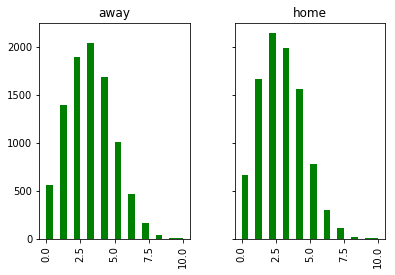

In [67]:
# Create a histogram of the “goals_against” variable by whether the game is home or away 
# a) Make the color of the histogram green
# b) Set the number of bins to be 20
# c) Make sure the two sub-histograms share the same ranges for the x-axis and y-axis
NHL_Game.hist(by='home_away', column='goals_against', color='green', bins=20, sharex=True, sharey=True)

## Part 3 - Correlation Analyses


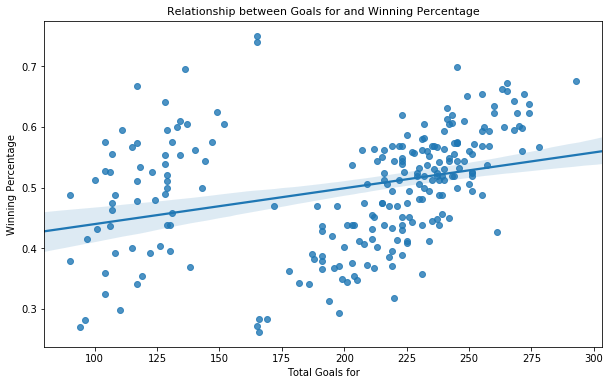

In [68]:
# In the “NHL_Team_R_Stats” dataframe, make a scatter plot to depict the relationship between the total number of goals for and the winning percentage. 
# a) Plot the total number of goals for on the x-axis and winning percentage on the y-axis.
# b) Add a regression line to the scatter plot.
# c) Make the title of the graph “Relationship between Goals for and Winning Percentage” and make the font size 11.
# d) Label the x-axis “Total Goals for” and label the y-axis “Winning Percentage”.

# a) & b) Create scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=NHL_Team_R_Stats, x='goals_for', y='win_pct')

# c) Add title with specific font size
plt.title('Relationship between Goals for and Winning Percentage', fontsize=11)

# d) Label the x and y axes
plt.xlabel('Total Goals for')
plt.ylabel('Winning Percentage')

plt.show()

In [69]:
# In the “NHL_Team_R_Stats” dataframe, calculate the correlation coefficient between total number of goals for and winning percentage.

correlation = NHL_Team_R_Stats['goals_for'].corr(NHL_Team_R_Stats['win_pct'])

print(f"Correlation between Goals For and Win Percentage: {correlation:.4f}")

Correlation between Goals For and Win Percentage: 0.3157


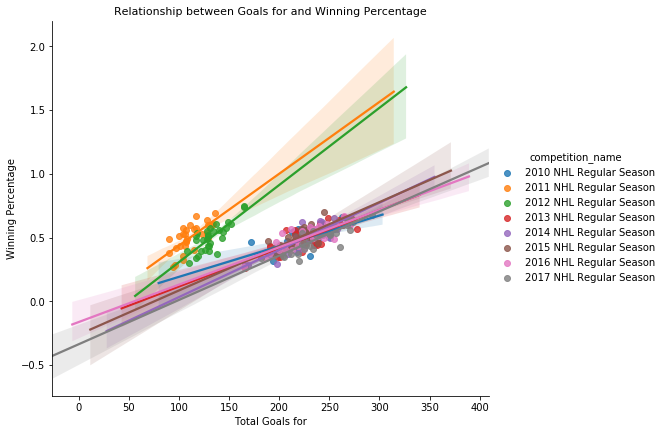

In [70]:
# Create a scatter plot of the total number of goals for and winning percentage similar to step 1 for regular season games. In this graph, group observations by “competition_name”.
# a) Plot the total number of goals for on the x-axis and winning percentage on the y-axis.
# b) Add a regression line to the scatter plot.
# c) Make the title of the graph “Relationship between Goals for and Winning Percentage” and make the font size 11.
# d) Label the x-axis “Total Goals for” and label the y-axis “Winning Percentage”.

g = sns.lmplot(
    data=NHL_Team_R_Stats, 
    x='goals_for', 
    y='win_pct', 
    hue='competition_name',
    height=6, 
    aspect=1.2
)

# c) Set the title and font size
# Since lmplot returns a FacetGrid, we use fig.suptitle or set_titles
plt.title('Relationship between Goals for and Winning Percentage', fontsize=11)

# d) Label the x and y axes
plt.xlabel('Total Goals for')
plt.ylabel('Winning Percentage')

plt.show()

In [71]:
# For the “NHL_Team_R_Stats” dataframe, delete observations of 2011 and 2012 seasons. Continue to name the dataframe “NHL_Team_R_Stats”.

exclude_seasons = ['2011 NHL Regular Season', '2012 NHL Regular Season'] # Adjust values to match your dataset format

NHL_Team_R_Stats = NHL_Team_R_Stats[~NHL_Team_R_Stats['competition_name'].isin(exclude_seasons)]


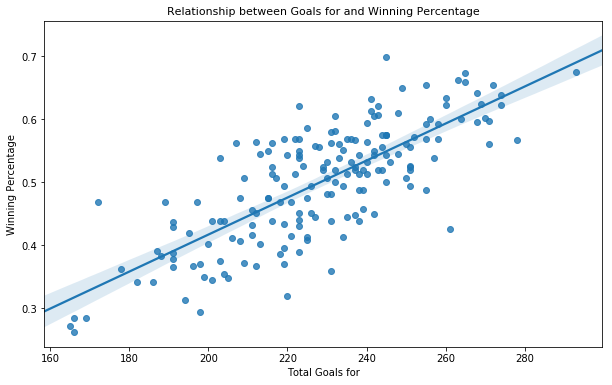

In [72]:
# In the new “NHL_Team_R_Stats” dataframe, create a scatter plot of total number of goals for and winning percentage.
# a) Plot the total number of goals for on the x-axis and winning percentage on the y-axis.
# b) Add a regression line to the scatter plot.
# c) Make the title of the graph “Relationship between Goals for and Winning Percentage” and make the font size 11.
# d) Label the x-axis “Total Goals for” and label the y-axis “Winning Percentage”.
# a) & b) Create scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=NHL_Team_R_Stats, x='goals_for', y='win_pct')

# c) Add title with specific font size
plt.title('Relationship between Goals for and Winning Percentage', fontsize=11)

# d) Label the x and y axes
plt.xlabel('Total Goals for')
plt.ylabel('Winning Percentage')

plt.show()

In [73]:
# In the “NHL_Team_R_Stats” dataframe, calculate the correlation coefficient between total number of goals for and winning percentage.

correlation = NHL_Team_R_Stats['goals_for'].corr(NHL_Team_R_Stats['win_pct'])

print(f"Correlation between Goals For and Win Percentage: {correlation:.4f}")

Correlation between Goals For and Win Percentage: 0.7706


In [ ]:
# Save dataframes as csv files. 
# a) Name the updated “NHL_Game” dataframe as “NHL_Game2”.
# b) Name the “NHL_Team_Stats” dataframe as “NHL_Team_Stats”.
# c) Name the “NHL_Team_R_Stats” dataframe as “NHL_Team_R_Stats”.
# d) Make sure to exclude the index as a column in the csv files.



## Uncomment this Section once your assignment is complete

In [75]:
# Save Dataframes as .csv files
NHL_Game.to_csv("NHL_Game2.csv", index=False)
NHL_Team_Stats.to_csv("NHL_Team_Stats.csv", index=False)
NHL_Team_R_Stats.to_csv("NHL_Team_R_Stats.csv", index=False)